# Comprehensive Notebook: Bias in NLP Models

## Introduction: Bias Analysis in Word Embeddings

#### Objective:

This notebook provides a comprehensive hands-on walkthrough for analyzing and mitigating gender bias in pretrained word embeddings, specifically using Word2Vec trained on Google News.

Key Learning Outcomes

By working through this notebook, you will:

* Understand how word embeddings capture semantic and societal associations.

* Learn to identify gender bias in embeddings using a defined gender direction.

* Visualize how different professions and social roles are represented in gender space.

* Apply de-biasing algorithms (neutralization and equalization) to correct biased word vectors.

* Evaluate how these interventions affect downstream associations and fairness.

#### Structure
The notebook is organized into the following key sections:

1. Setup and Model Loading

-  Installing required packages and loading pretrained Word2Vec.

2. Bias Detection

-  Defining gender direction using word pairs like ('he', 'she')

-  Measuring gender association (bias scores) for a variety of words and professions.

3.  Visualization

-  Using dimensionality reduction (PCA/t-SNE) to visually inspect biased embeddings.

4. Debiasing Techniques

- Applying neutralize to remove gender direction from neutral words.

- Using equalize to symmetrize explicitly gendered word pairs.

5. Evaluation

- Comparing bias scores before and after mitigation.

- Highlighting the impact of de-biasing on model fairness.

---

# Gender Bias in Word Embeddings (Word2Vec)

In [ ]:
!pip install gensim

In [ ]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')

Downloads and loads the Word2Vec model trained on 100 billion words from Google News. This model captures semantic and syntactic relationships between words.

In [ ]:
# Gender direction
gender_direction = model['he'] - model['she']

Word embeddings represent words as high-dimensional vectors.

Subtracting model['she'] from model['he'] gives a vector that points in the direction of masculinity.

This vector becomes a reference for measuring how much other words are aligned with male or female semantics.

In [ ]:
import numpy as np
professions = ['doctor', 'nurse', 'engineer', 'teacher']
bias_scores = {p: np.dot(model[p], gender_direction) for p in professions}
bias_scores

{'doctor': -0.3586461,
 'nurse': -1.7857399,
 'engineer': 0.60996526,
 'teacher': -1.030216}

Defines a list of professions to analyze gender bias. Likely compares each word's vector projection on a gender direction (e.g., between 'he' and 'she') to quantify bias.

---

# Racial Bias in Word Embeddings (GloVe)

In [ ]:
from gensim.models import KeyedVectors
import numpy as np
# Load GloVe vectors (converted to word2vec format)
model = api.load('glove-wiki-gigaword-100')

Downloads and loads the GloVe word embeddings (100-dimensional version trained on Wikipedia + Gigaword corpus).

GloVe: Global Vectors for Word Representation.

Trained on Wikipedia 2014 + Gigaword 5 (~6B tokens).

Each word vector is 100 dimensions.

In [ ]:
white_words = ['white', 'caucasian']
black_words = ['black', 'african']
race_direction = model['white'] - model['black']

This calculates a race direction vector in the embedding space — from 'black' to 'white'.

Think of it like drawing a line between 'black' and 'white' in the high-dimensional space.

This vector captures semantic differences the model has learned between the two words.

In [ ]:
professions = ['criminal', 'lawyer', 'gang', 'scholar']
bias_scores = {p: np.dot(model[p], race_direction) for p in professions}
bias_scores

{'criminal': 0.47072226,
 'lawyer': 1.8238053,
 'gang': -1.9767607,
 'scholar': -1.0661284}

This code computes how strongly each profession word aligns with a racial bias vector (from "black" to "white").
Positive scores suggest association with "white", negative scores with "black", revealing potential racial bias in the embeddings.

---

# Religious Bias in Word Embeddings (FastText)

In [ ]:
model = api.load('fasttext-wiki-news-subwords-300')
import numpy as np

This line loads the FastText word embedding model trained on Wikipedia + news data, where each word is represented using 300-dimensional vectors and includes subword (character n-gram) information.

fasttext-wiki-news-subwords-300:

Trained on English Wikipedia and news articles.

Uses subwords, so it can handle out-of-vocabulary words better than Word2Vec/GloVe.

Embeddings include morphological structure, making it robust for rare or misspelled words.



In [ ]:
religion_direction = model['christian'] - model['muslim']

In [ ]:
terms = ['terrorist', 'peaceful', 'violent', 'charity']
bias_scores = {t: np.dot(model[t], religion_direction) for t in terms}
bias_scores

{'terrorist': -0.24429306,
 'peaceful': -0.14097627,
 'violent': -0.1424201,
 'charity': -0.04280263}

This code computes how much each word in terms aligns with the religion direction vector from 'muslim' to 'christian'.
A positive score means the word is closer to 'christian', while a negative score means it leans toward 'muslim', revealing religious bias in the embedding space.



---

# Contextual Bias in BERT

In [ ]:
from transformers import pipeline
fill_mask = pipeline('fill-mask', model='bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


This line initializes a masked language model pipeline using BERT (base, uncased), enabling you to analyze contextual bias by predicting masked words.
It lets you test how BERT completes sentences like "The [MASK] is a nurse." to reveal bias based on surrounding context.



In [ ]:
fill_mask('The doctor is a [MASK].')

[{'score': 0.1044514924287796,
  'token': 3460,
  'token_str': 'doctor',
  'sequence': 'the doctor is a doctor.'},
 {'score': 0.028502531349658966,
  'token': 4393,
  'token_str': 'vampire',
  'sequence': 'the doctor is a vampire.'},
 {'score': 0.027545074000954628,
  'token': 11067,
  'token_str': 'genius',
  'sequence': 'the doctor is a genius.'},
 {'score': 0.016155878081917763,
  'token': 2158,
  'token_str': 'man',
  'sequence': 'the doctor is a man.'},
 {'score': 0.014799191616475582,
  'token': 6821,
  'token_str': 'nurse',
  'sequence': 'the doctor is a nurse.'}]

This sends the sentence to BERT with a masked token and asks it to predict the most likely word to fill in [MASK].
The predictions (e.g., "man", "woman", "professional") reveal contextual biases BERT has learned from its training data.

In [ ]:
fill_mask('The nurse is a [MASK].')

[{'score': 0.1860848218202591,
  'token': 6821,
  'token_str': 'nurse',
  'sequence': 'the nurse is a nurse.'},
 {'score': 0.1292211413383484,
  'token': 3460,
  'token_str': 'doctor',
  'sequence': 'the nurse is a doctor.'},
 {'score': 0.0724407359957695,
  'token': 2450,
  'token_str': 'woman',
  'sequence': 'the nurse is a woman.'},
 {'score': 0.02131066285073757,
  'token': 5160,
  'token_str': 'lawyer',
  'sequence': 'the nurse is a lawyer.'},
 {'score': 0.014307888224720955,
  'token': 7522,
  'token_str': 'physician',
  'sequence': 'the nurse is a physician.'}]

In [ ]:
fill_mask('The terrorist was a [MASK].')

[{'score': 0.0654190331697464,
  'token': 7966,
  'token_str': 'fool',
  'sequence': 'the terrorist was a fool.'},
 {'score': 0.04228513687849045,
  'token': 9452,
  'token_str': 'terrorist',
  'sequence': 'the terrorist was a terrorist.'},
 {'score': 0.041286032646894455,
  'token': 2158,
  'token_str': 'man',
  'sequence': 'the terrorist was a man.'},
 {'score': 0.040299732238054276,
  'token': 6359,
  'token_str': 'killer',
  'sequence': 'the terrorist was a killer.'},
 {'score': 0.021483393386006355,
  'token': 16592,
  'token_str': 'coward',
  'sequence': 'the terrorist was a coward.'}]

In [ ]:
fill_mask('The engineer is a [MASK].')

[{'score': 0.03255537152290344,
  'token': 5160,
  'token_str': 'lawyer',
  'sequence': 'the engineer is a lawyer.'},
 {'score': 0.03051907569169998,
  'token': 3010,
  'token_str': 'canadian',
  'sequence': 'the engineer is a canadian.'},
 {'score': 0.029691770672798157,
  'token': 3992,
  'token_str': 'engineer',
  'sequence': 'the engineer is a engineer.'},
 {'score': 0.023985283449292183,
  'token': 13666,
  'token_str': 'contractor',
  'sequence': 'the engineer is a contractor.'},
 {'score': 0.02332036755979061,
  'token': 6831,
  'token_str': 'civilian',
  'sequence': 'the engineer is a civilian.'}]

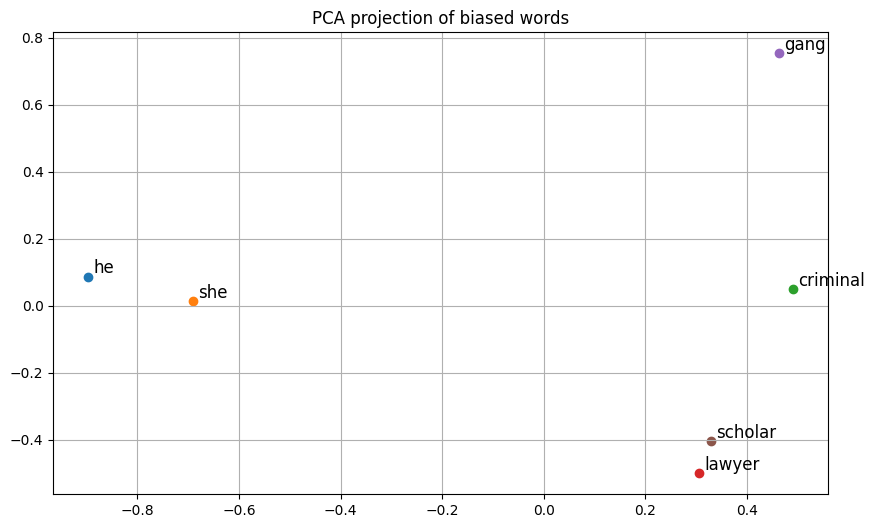

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_words(words, model, gender_direction):
    vecs = [model[w] for w in words]
    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(vecs)

    plt.figure(figsize=(10, 6))
    for i, word in enumerate(words):
        x, y = vecs_2d[i]
        plt.scatter(x, y)
        plt.text(x+0.01, y+0.01, word, fontsize=12)
    plt.title("PCA projection of biased words")
    plt.grid(True)
    plt.show()

# Combine gendered words and professions
plot_words(["he", "she"] + professions, model, gender_direction)

The plot_words function reduces word vectors to 2D using PCA and plots them to visually inspect gender bias — showing how close professions (e.g., "doctor", "nurse") are to gendered terms like "he" and "she".
This helps reveal clustering patterns and directional bias in the embedding space.

## Measuring Bias Using WEAT

Objective: Use WEAT (Word Embedding Association Test) to quantify association.

This step requires a WEAT implementation. If not installed, demonstrate manually with cosine similarities between target sets.

In [ ]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

male_words = ["he", "him", "man", "male", "father"]
female_words = ["she", "her", "woman", "female", "mother"]

target_professions = ["nurse", "engineer", "scientist", "teacher", "lawyer"]

for word in target_professions:
    sim_male = np.mean([cosine_similarity(model[word], model[m]) for m in male_words])
    sim_female = np.mean([cosine_similarity(model[word], model[f]) for f in female_words])
    print(f"{word:10} | Male Sim: {sim_male:.4f} | Female Sim: {sim_female:.4f}")

nurse      | Male Sim: 0.4423 | Female Sim: 0.5394
engineer   | Male Sim: 0.4332 | Female Sim: 0.3901
scientist  | Male Sim: 0.4466 | Female Sim: 0.4251
teacher    | Male Sim: 0.4503 | Female Sim: 0.4808
lawyer     | Male Sim: 0.4241 | Female Sim: 0.4230


This code evaluates gender bias in word embeddings by comparing how closely each profession (e.g., "nurse", "engineer") aligns with male and female word groups, using cosine similarity.

cosine_similarity() computes how directionally similar two vectors are.

For each profession in target_professions, the code:

- Calculates average similarity to male words (e.g., "he", "man").

- Calculates average similarity to female words (e.g., "she", "woman").

The printed results indicate whether a profession is more semantically associated with men or women in the embedding space — revealing potential gender bias.